<a href="https://colab.research.google.com/github/dy8656/ESM-Summer-School-2026---Mumax3/blob/main/mumax3_ESM_Summer_School_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mumax3 in google colaboratory**

This is a modified version of the google colab notbook provided by the mumax team at https://mumax.github.io/

# Introduction to the code

## What is MUMAX3?
* Free finite-difference based micromagnetic simulation package
* GPU-accelerated nvidia GPU required
* Developed at DyNaMat (Ugent) by Arne Vansteenkiste
* Latest official release mumax3.12
* Active community
* Documented API mumax.github.io
* Open source (GPLv3) github.com/mumax/3
* Mainly written in Go
* CUDA C kernels for heavy lifting
* Scripting language + Web GUI
* Well tested (unit tests + NIST standard problems)

**mumax⁺**

https://mumax.github.io/plus/

mumax⁺ is a versatile and extensible GPU-accelerated micromagnetic simulator written in C++ and CUDA with a Python interface. This project is in development alongside mumax³.

## About Google colaboratory

Google colaboratory is a research tool mainly used by researchers in the field of machine learning. The main purpose of this tool is to run python code in jupyter notebooks. These notebooks run on a virtual linux machine private to your gmail account. This means that you will need a gmail account to execute programs in a google colaboratory session. If you have a gmail account you should be able to copy this jupyter notebook to your google drive and execute the code cells.

To run mumax3 simulations, you do not need to write any python code. So you might wonder how we can use this jupyter notebook environment to run mumax3 simulations. The trick here is that you can execute shell commands by typing an exclamation mark followed by the command, as shown in the code cell below. If you run this code cell, the shell will print out the operating system of the virtual machine. Having the ability to run shell commands suffices to install and run mumax3 simulations, as demonstrated in the sections below.

In [ ]:
! echo "This machine runs" $(uname)

This machine runs Linux


## Installing mumax3

To install mumax3.12 on this virtual machine, you can run the cell below. This might take a few minutes. When the installation is done, you can collapse this section to get a clean workspace.

In [ ]:
try:
    import google.colab
except ImportError:
    pass
else:
    # Download the mumax3 binary
    !wget https://mumax.ugent.be/mumax3-binaries/mumax3.12_linux_cuda12.9.tar.gz
    !tar -xvf mumax3.12_linux_cuda12.9.tar.gz
    !rm mumax3.12_linux_cuda12.9.tar.gz
    !rm -rf mumax3.12 && mv mumax3.12_linux_cuda12.9 mumax3.12
    #update the PATH environment variable
    import os
    os.environ['PATH'] += ":/content/mumax3.12"
    # Download an examplary script
    !wget https://raw.githubusercontent.com/JeroenMulkers/mumax3-tutorial/master/standardproblem4.mx3 -O standardproblem4.mx3

--2026-08-04 09:31:32--  https://mumax.ugent.be/mumax3-binaries/mumax3.12_linux_cuda12.9.tar.gz
Resolving mumax.ugent.be (mumax.ugent.be)... 157.193.40.77
Connecting to mumax.ugent.be (mumax.ugent.be)|157.193.40.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 287329660 (274M) [application/x-gzip]
Saving to: ‘mumax3.12_linux_cuda12.9.tar.gz’

mumax3.12_linux_cud 100%[===================>] 274.02M  24.1MB/s    in 13s     

2026-08-04 09:31:45 (21.6 MB/s) - ‘mumax3.12_linux_cuda12.9.tar.gz’ saved [287329660/287329660]

mumax3.12_linux_cuda12.9/
mumax3.12_linux_cuda12.9/LICENSE
mumax3.12_linux_cuda12.9/mumax3
mumax3.12_linux_cuda12.9/mumax3-server
mumax3.12_linux_cuda12.9/mumax3-convert
mumax3.12_linux_cuda12.9/lib/
mumax3.12_linux_cuda12.9/lib/libcurand.so.10
mumax3.12_linux_cuda12.9/lib/libcufft.so.11
--2026-08-04 09:31:51--  https://raw.githubusercontent.com/JeroenMulkers/mumax3-tutorial/master/standardproblem4.mx3
Resolving raw.githubusercontent.com (raw.gi

## Running a mumax3 script

You can open the filebrowser for this virtual machine on the left side of this page. Here you should see a mumax3 script named standardproblem4.mx3. You should be able to open this file with a double click or have a look via

In [ ]:
!cat standardproblem4.mx3

SetGridsize(128, 32, 1)
SetCellsize(500e-9/128, 125e-9/32, 3e-9)

Msat  = 800e3
Aex   = 13e-12
alpha = 0.02

m = uniform(1, .1, 0)
relax()
save(m)    // relaxed state

autosave(m, 200e-12)
tableautosave(10e-12)

B_ext = vector(-24.6E-3, 4.3E-3, 0)
run(1e-9)


Mumax3’s scripting language is a subset of golang.

```
// saturation magnetization
Msat = 5e6

// declare new variable
Freq := 1e9

for i:=0; i<10; i++ {
  print(i)
}

if 1+8 == 9 {
  print(“Of course 1+8=9”)
}
```

To execute the script run the code cell below.

In [ ]:
!mumax3 standardproblem4.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.150
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 14fb70a6932a
//Timestamp: 2026-08-04 09:36:48
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: standardproblem4.out/
//starting GUI at http://127.0.0.1:35367
SetGridsize(128, 32, 1)
SetCellsize(500e-9/128, 125e-9/32, 3e-9)
Msat = 800e3
Aex = 13e-12
alpha = 0.02
m = uniform(1, .1, 0)
relax()
//Did not use cached kernel: open /tmp/mumax3kernel_[128 32 1

If you ran the code, then there should be a directory named standardproblem4.out (you might need to click on the refresh button in the filebrowser). This directory contains the output files of the simulation. mumax3-convert can now be used to convert the ovf files to images, as demonstrated in the cell below.

In [ ]:
!mumax3-convert -png standardproblem4.out/*.ovf

standardproblem4.out/m000000.ovf
standardproblem4.out/m000001.ovf
standardproblem4.out/m000002.ovf
standardproblem4.out/m000003.ovf
standardproblem4.out/m000004.ovf
standardproblem4.out/m000005.ovf
standardproblem4.out/m000006.ovf
[ ok ] standardproblem4.out/m000000.ovf	-> standardproblem4.out/m000000.png
[ ok ] standardproblem4.out/m000002.ovf	-> standardproblem4.out/m000002.png
[ ok ] standardproblem4.out/m000001.ovf	-> standardproblem4.out/m000001.png
[ ok ] standardproblem4.out/m000004.ovf	-> standardproblem4.out/m000004.png
[ ok ] standardproblem4.out/m000003.ovf	-> standardproblem4.out/m000003.png
[ ok ] standardproblem4.out/m000006.ovf	-> standardproblem4.out/m000006.png
[ ok ] standardproblem4.out/m000005.ovf	-> standardproblem4.out/m000005.png
7 files converted,  0 skipped,  0 failed


## Explaining the input file

### DISCRETIZATION
The discretization of the example is via a rectangular simulation box (origin in the center)

```
SetGridsize(128, 32, 1)
SetCellsize(500e-9/128, 125e-9/32, 3e-9)
```

with
* Single regular rectangular grid
* Uniform magnetization inside cell $\boldsymbol{m}_{ijk} = \boldsymbol{m}(x_i , y_i , z_i)$
* Cell size < exchange length


Periodic boundary condition (PBC) values are number of virtual repetitions of the
simulation box used to calculate dipolar interactions

```
setpbc(4,0,0)
```

Various shapes are also possible, but not part of this tutorial. Please see documentation.

### MATERIALS PARAMETERS

```
Msat  = 800e3
Aex   = 13e-12
alpha = 0.02
```
* Material parameters are predefined, they can not be created
* There are vector and scalar material parameters
```
AnisU = vector(1, 0, 0)
```
* Material parameters can be functions of time
```
f := 500e6
Ku1 = 500 * sin(2*pi*f*t)
```

## INITIAL MAGNETIZATION

```
m = uniform(1, .1, 0)
```

Different ways to set the magnetization:

```
Uniform(mx, my, mz)
RandomMag()
RandomMagSeed(seed)
TwoDomain(
mx1, my1, mz1,
my2, my2, mz2,
mx3, my3, mz3)
Vortex(circ, pol)
AntiVortex(circ, pol)
VortexWall(mxLeft, mxRight, circ, pol)
NeelSkyrmion(charge, pol)
BlochSkyrmion(charge, pol)
Conical(kVec, coneDir, coneAngle)
Helical(kVec)
```

via define methods

```
Transl(dx,dy,dz)
Scale(sx,sy,sz)
Add(ratio, config)
RotZ(angle)
```

## RUN/RELAX/MINIMIZE

* Solving the LLG equation (time integration)
```
run(timeperiod)
steps(100)
```

* Minimizing the energy
```
relax() // LLG without precession
Minimize() // steepest descent[1]
```

## OUTPUT
3 output media:
* log file for input, logging and printing
* table.txt ( t, mx, my, mz, … )
```
tableadd(E_total)
tableaddvar(myVar,”myVar”,”unit”)
tablesave() // write single line
tableautosave(1e-12) // write periodically
```
* .ovf files for scalar and vector fields
```
save(Edens_total)
saveas(Edens_total,”edens.ovf”)
autosave(Edens_total, 1e-10) // write perdiodically
```

## THE INTERACTIONS
Effective field terms
* Demagnetization
* Exchange
* Anisotropy
* Dzyaloshinskii-Moriya
* External field
* Thermal field
* Custom field

See documentation.

## UNITS

* Length in m
* Energies in J
* Saturation Magnetisation in A/m

##  GPU benchmark example

(not required to run)

In [ ]:
!wget https://raw.githubusercontent.com/mumax/3/refs/heads/master/bench/bench.mx3

--2026-08-03 11:43:57--  https://raw.githubusercontent.com/mumax/3/refs/heads/master/bench/bench.mx3
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 487 [text/plain]
Saving to: ‘bench.mx3’

bench.mx3           100%[===================>]     487  --.-KB/s    in 0s      

2026-08-03 11:43:58 (36.9 MB/s) - ‘bench.mx3’ saved [487/487]



In [ ]:
!mumax3 bench.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.196
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: cb3502fba2c4
//Timestamp: 2026-08-03 11:44:26
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: bench.out/
//starting GUI at http://127.0.0.1:35367
msat = 800e3
aex = 13e-12
alpha = 0.01
c := 4e-9
setcellsize(c, c, c)
setsolver(2)
for e := 5; e < 14; e++ {
	n := pow(2, e)
	setgridsize(n, n, 1)
	print(n, "x", n)
	steps(1)
	b_ext = vector(0, 0.01, 0)
	m 

In [ ]:
!cat bench.out/benchmark.txt

1024 5.907537859659227e+06 1.6906337195843912e-14
4096 1.9365499983546887e+07 1.6975339996818884e-14
16384 7.864102699114218e+07 1.6960106741379807e-14
65536 1.5212491894077685e+08 1.6952234650767378e-14
262144 1.949975102008199e+08 1.6948249155837326e-14
1.048576e+06 2.4350746680452052e+08 1.6946219094668855e-14
4.194304e+06 2.328818860304582e+08 1.694520866999972e-14
1.6777216e+07 2.326974218787788e+08 1.6944710532630896e-14
6.7108864e+07 2.0598450673031443e+08 1.694444864636619e-14


# Example 1 of the Mumax Tutorial - Phase diagram.

We are considering a ferromagnetic cube with a uniaxial anisotropy

$K_u= 0.1 K_M= 0.1 \frac{\mu_0M_s^2}{2}$

**Task**

Calculate the quasi uniform domain limit of a cubic magnetic particle. This is the size L of equal energy for the flower state and the vortex state.

Let obtain the input files from the original tutorial

In [ ]:
!wget https://mumax.ugent.be/mumax3-workshop/example_scripts/session3_example1a.txt
!wget https://mumax.ugent.be/mumax3-workshop/example_scripts/session3_example1b.txt

--2026-08-04 10:40:52--  https://mumax.ugent.be/mumax3-workshop/example_scripts/session3_example1a.txt
Resolving mumax.ugent.be (mumax.ugent.be)... 157.193.40.77
Connecting to mumax.ugent.be (mumax.ugent.be)|157.193.40.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 988 [text/plain]
Saving to: ‘session3_example1a.txt’

session3_example1a. 100%[===================>]     988  --.-KB/s    in 0s      

2026-08-04 10:40:53 (404 MB/s) - ‘session3_example1a.txt’ saved [988/988]

--2026-08-04 10:40:53--  https://mumax.ugent.be/mumax3-workshop/example_scripts/session3_example1b.txt
Resolving mumax.ugent.be (mumax.ugent.be)... 157.193.40.77
Connecting to mumax.ugent.be (mumax.ugent.be)|157.193.40.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1004 [text/plain]
Saving to: ‘session3_example1b.txt’

session3_example1b. 100%[===================>]    1004  --.-KB/s    in 0s      

2026-08-04 10:40:54 (568 MB/s) - ‘session3_example1b.txt’ save

and show them

In [ ]:
!cat session3_example1a.txt
!cat session3_example1b.txt

/*****************************************************************  

  Description: 

   This mumax3 script computes the total energy of a relaxed 
   vortex state in a ferromagnetic cube as a function of the side 
   length of the cube. 

   This file is written for the mumax3 workshop organised for the 
   spintronic seminar series in the summer of 2020. For more 
   information go to https://www.mumax.ugent.be/mumax3-workshop
  
  Authors:

   Dr. Jonathan Leliaert (jonathan.leliaert@ugent.be)
   Dr. Jeroen Mulkers    (jeroen.mulkers@ugent.be)

******************************************************************/

N := 64
setgridsize(N,N,N)

Lmin := 8.0
Lmax := 9.0
Lstep := 0.05

L := Lmin
setcellsize(L/N,L/N,L/N)

Msat = sqrt(2/mu0)
Aex = 1.0
Ku1 = 0.1
anisU = vector(1,0,0) 

m = vortex(1,-1)

tableadd(E_total)
tableaddvar(L,"L","")

for L=Lmin ; L<=Lmax; L+=Lstep {
    setcellsize(L/N,L/N,L/N)
    minimize()
    tablesave()
}
/*******************************************************

Right click on the filebrowser to add a new file. Open the file and write your first mumax3 script. Run this script as demonstrated above.

It should be noted that the constabrs are expressed in terms of the magnetostatic energy density $K_m=\frac{\mu_0 M_s}{2}$. Hence, the exchange length $l_{ex}=\sqrt{\frac{A}{K_m}}$.

Cell sizes small enough?
$\frac{L}{N}: 0.125 l_{ex} \rightarrow 0.141 l_{ex}$ - Yes

Run the examples. This could take a few minutes.

In [ ]:
!mumax3 session3_example1a.txt

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.150
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 14fb70a6932a
//Timestamp: 2026-08-04 10:43:44
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: session3_example1a.out/
//starting GUI at http://127.0.0.1:35367
N := 64
setgridsize(N, N, N)
Lmin := 8.0
Lmax := 9.0
Lstep := 0.05
L := Lmin
setcellsize(L/N, L/N, L/N)
Msat = sqrt(2 / mu0)
Aex = 1.0
Ku1 = 0.1
anisU = vector(1, 0, 0)
m = vortex(1, -1)
tablea

In [ ]:
!mumax3 session3_example1b.txt

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.150
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 14fb70a6932a
//Timestamp: 2026-08-04 10:55:02
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: session3_example1b.out/
//starting GUI at http://127.0.0.1:35367
N := 64
setgridsize(N, N, N)
Lmin := 8.0
Lmax := 9.0
Lstep := 0.05
L := Lmin
setcellsize(L/N, L/N, L/N)
Msat = sqrt(2 / mu0)
Aex = 1.0
Ku1 = 0.1
anisU = vector(1, 0, 0)
m = uniform(1.0, 0, 0.00

Lets plot the total energy as a function of the cell size

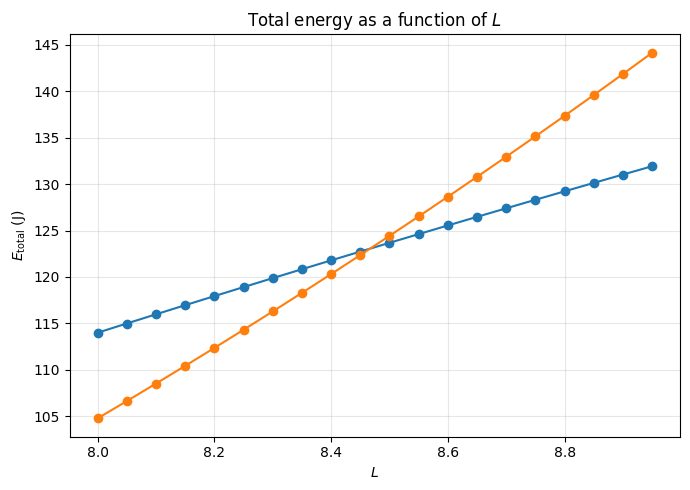

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the name of your data file
filename = "session3_example1a.out/table.txt"

# Columns are counted from zero:
# 0: t, 1: mx, 2: my, 3: mz, 4: E_total, 5: L
E_total, L = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(4, 5),
    unpack=True
)

plt.figure(figsize=(7, 5))
plt.plot(L, E_total, marker="o", linestyle="-")

# Replace this with the name of your data file
filename = "session3_example1b.out/table.txt"
E_total, L = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(4, 5),
    unpack=True
)
plt.plot(L, E_total, marker="o", linestyle="-")

plt.xlabel(r"$L$")
plt.ylabel(r"$E_{\mathrm{total}}$ (J)")
plt.title(r"Total energy as a function of $L$")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("E_total_vs_L.pdf")
plt.show()

## Exercise 1
1. From the original setup, double the magnetocrystalline anisotropy. What do you observe and explain?
2. (Optional at home) Vary the magnetocrystaline anisotropy from 0.1 to 0.2 in 0.02 steps. Use just one input script for each magnetic configuration. Visualise the critical size as a function of the anisotropy.

## Solution Exercise 1.1

In [ ]:
f = open('example1b_exercise.mx3', 'w')
a = """\
N := 64
setgridsize(N,N,N)

Lmin := 8.0
Lmax := 10.0
Lstep := 0.05

L := Lmin
setcellsize(L/N,L/N,L/N)

Msat = sqrt(2/mu0)
Aex = 1.0
Ku1 = 0.2
anisU = vector(1,0,0)

m = uniform(1.0, 0, 0.001)

tableadd(E_total)
tableaddvar(L,"L","")

for L=Lmin ; L<=Lmax; L+=Lstep {
    setcellsize(L/N,L/N,L/N)
    minimize()
    tablesave()
}
"""
print(a,file=f)
f.close()

f = open('example1a_exercise.mx3', 'w')
a = """\
N := 64
setgridsize(N,N,N)

Lmin := 8.0
Lmax := 10.0
Lstep := 0.05

L := Lmin
setcellsize(L/N,L/N,L/N)

Msat = sqrt(2/mu0)
Aex = 1.0
Ku1 = 0.2
anisU = vector(1,0,0)

m = vortex(1,-1)

tableadd(E_total)
tableaddvar(L,"L","")

for L=Lmin ; L<=Lmax; L+=Lstep {
    setcellsize(L/N,L/N,L/N)
    minimize()
    tablesave()
}
"""
print(a,file=f)
f.close()


In [ ]:
!mumax3 example1a_exercise.mx3
!mumax3 example1b_exercise.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.150
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 14fb70a6932a
//Timestamp: 2026-08-04 11:16:15
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example1a_exercise.out/
//starting GUI at http://127.0.0.1:35367
N := 64
setgridsize(N, N, N)
Lmin := 8.0
Lmax := 10.0
Lstep := 0.05
L := Lmin
setcellsize(L/N, L/N, L/N)
Msat = sqrt(2 / mu0)
Aex = 1.0
Ku1 = 0.2
anisU = vector(1, 0, 0)
m = vortex(1, -1)
table

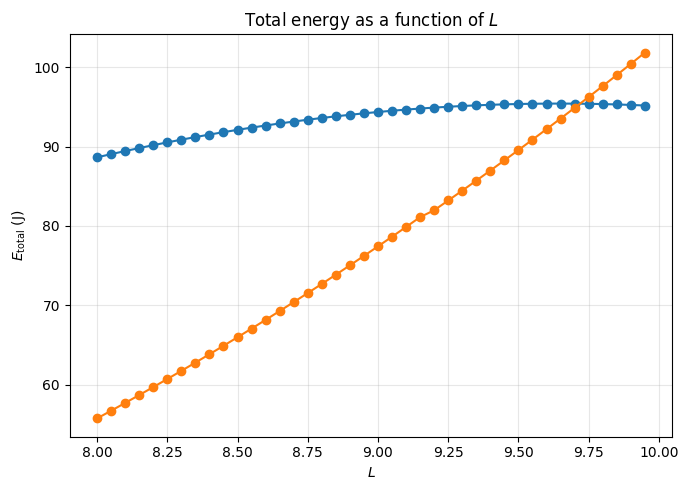

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the name of your data file
filename = "example1a_exercise.out/table.txt"

# Columns are counted from zero:
# 0: t, 1: mx, 2: my, 3: mz, 4: E_total, 5: L
E_total, L = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(4, 5),
    unpack=True
)

plt.figure(figsize=(7, 5))
plt.plot(L, E_total, marker="o", linestyle="-")

# Replace this with the name of your data file
filename = "example1b_exercise.out/table.txt"
E_total, L = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(4, 5),
    unpack=True
)
plt.plot(L, E_total, marker="o", linestyle="-")

plt.xlabel(r"$L$")
plt.ylabel(r"$E_{\mathrm{total}}$ (J)")
plt.title(r"Total energy as a function of $L$")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("E_total_vs_L.pdf")
plt.show()

## Solution Exercise 1.2

In [ ]:
f = open('example1b_exercise12.mx3', 'w')
a = """\
N := 64
setgridsize(N,N,N)

Lmin := 8.0
Lmax := 10.0
Lstep := 0.05

L := Lmin
setcellsize(L/N,L/N,L/N)

Msat = sqrt(2/mu0)
Aex = 1.0
Ku1min := 0.1
Ku1max := 0.2
Ku1step := 0.01
K := Ku1min
anisU = vector(1,0,0)

m = uniform(1.0, 0, 0.001)

tableadd(E_total)
tableaddvar(L,"L","")
tableaddvar(K,"K","")

for K=Ku1min ; K<=Ku1max; K+=Ku1step {
    Ku1 = K
    for L=Lmin ; L<=Lmax; L+=Lstep {
        setcellsize(L/N,L/N,L/N)
        minimize()
        tablesave()
    }
}
"""
print(a,file=f)
f.close()

f = open('example1a_exercise12.mx3', 'w')
a = """\
N := 64
setgridsize(N,N,N)

Lmin := 8.0
Lmax := 10.0
Lstep := 0.05

L := Lmin
setcellsize(L/N,L/N,L/N)

Msat = sqrt(2/mu0)
Aex = 1.0
Ku1min := 0.1
Ku1max := 0.2
Ku1step := 0.01
K := Ku1min
anisU = vector(1,0,0)

m = vortex(1,-1)

tableadd(E_total)
tableaddvar(L,"L","")
tableaddvar(K,"K","")

for K=Ku1min ; K<=Ku1max; K+=Ku1step {
    Ku1 = K
    for L=Lmin ; L<=Lmax; L+=Lstep {
        setcellsize(L/N,L/N,L/N)
        minimize()
        tablesave()
    }
}
"""
print(a,file=f)
f.close()

In [ ]:
!mumax3 example1a_exercise12.mx3
!mumax3 example1b_exercise12.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.150
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 14fb70a6932a
//Timestamp: 2026-08-04 11:34:20
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example1a_exercise12.out/
//starting GUI at http://127.0.0.1:35367
N := 64
setgridsize(N, N, N)
Lmin := 8.0
Lmax := 10.0
Lstep := 0.05
L := Lmin
setcellsize(L/N, L/N, L/N)
Msat = sqrt(2 / mu0)
Aex = 1.0
Ku1min := 0.1
Ku1max := 0.2
Ku1step := 0.01
K := Ku1min

# Example 2 of Mumax Tutorial - Skyrmion Racetrack

Skyrmion driven by spin transfer torques (STT) in a chiral ferromagnetic strip. THis work is based in the article Nature Nanotechnology volume 8, pages 839–844 (2013).

System: Co/Pt strip
* Ferromagnetic
* Perpendicular Magnetic Anisotropy (PMA)
* Interfacially-induced Dzyaloshinskii-Moriya interaction (iDMI)
* Uniform spin-polarized current along the length of the strip

Note on the cell size:

In chiral ferromagnets, the magnetization might vary on a much
smaller length scale than the exchange length!
autosave(m,4e-10)
tableAutosave(1e-11)
tableAdd(ext_bubblepos)
run(10e-9)
When choosing the cell size make sure that maxAngle is small
enough during the simulation (let's say $<0.35rad$)
In this example print(maxAngle) returns 0.26rad → cell size OK

In [ ]:
!wget https://mumax.ugent.be/mumax3-workshop/example_scripts/session3_example2.txt

--2026-08-03 12:22:34--  https://mumax.ugent.be/mumax3-workshop/example_scripts/session3_example2.txt
Resolving mumax.ugent.be (mumax.ugent.be)... 157.193.40.77
Connecting to mumax.ugent.be (mumax.ugent.be)|157.193.40.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 986 [text/plain]
Saving to: ‘session3_example2.txt’

session3_example2.t 100%[===================>]     986  --.-KB/s    in 0s      

2026-08-03 12:22:35 (364 MB/s) - ‘session3_example2.txt’ saved [986/986]



In [ ]:
f = open('example2.mx3', 'w')
a = """\
setgridsize(256,64,1)
setcellsize(1e-9,1e-9,1e-9)
setpbc(4,0,0)

Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0,0,1)
alpha = 0.1

m = neelskyrmion(-1, 1).transl(-40e-9,0,0)
minimize()

Pol = 0.4
xi = 0.2
j = vector(-1e12,0,0) // A/m2

autosave(m,4e-10)
tableAutosave(1e-11)
tableAdd(ext_bubblepos)

run(10e-9)
"""
print(a,file=f)
f.close()

Concerning the inital state:
```
neelskyrmion(-1, 1)
```
The first index is the winding number (skyrmion or antiskyrmion), where the second is the polarisation.

In [ ]:
!mumax3 session3_example2.txt

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.196
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: cb3502fba2c4
//Timestamp: 2026-08-03 12:23:08
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: session3_example2.out/
//starting GUI at http://127.0.0.1:35367
setgridsize(256, 64, 1)
setcellsize(1e-9, 1e-9, 1e-9)
setpbc(4, 0, 0)
//resizing...
Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0, 0, 1)
alpha = 0.1
m = neelskyrmion(-1, 1

In [ ]:
!mumax3-convert -png session3_example2.out/*.ovf

session3_example2.out/m000000.ovf
session3_example2.out/m000001.ovf
session3_example2.out/m000002.ovf
session3_example2.out/m000003.ovf
session3_example2.out/m000004.ovf
session3_example2.out/m000005.ovf
session3_example2.out/m000006.ovf
session3_example2.out/m000007.ovf
session3_example2.out/m000008.ovf
session3_example2.out/m000009.ovf
session3_example2.out/m000010.ovf
session3_example2.out/m000011.ovf
session3_example2.out/m000012.ovf
session3_example2.out/m000013.ovf
session3_example2.out/m000014.ovf
session3_example2.out/m000015.ovf
session3_example2.out/m000016.ovf
session3_example2.out/m000017.ovf
session3_example2.out/m000018.ovf
session3_example2.out/m000019.ovf
session3_example2.out/m000020.ovf
session3_example2.out/m000021.ovf
session3_example2.out/m000022.ovf
session3_example2.out/m000023.ovf
session3_example2.out/m000024.ovf
session3_example2.out/m000025.ovf
[ ok ] session3_example2.out/m000000.ovf	-> session3_example2.out/m000000.png
[ ok ] session3_example2.out/m000001.o

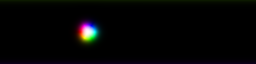

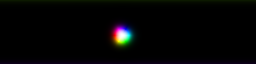

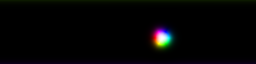

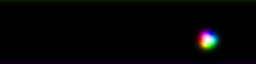

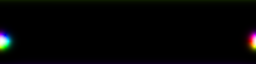

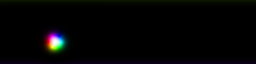

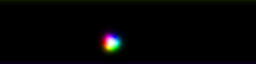

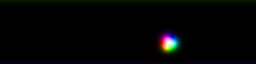

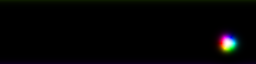

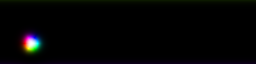

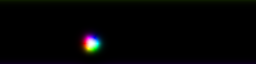

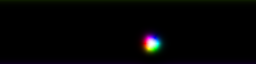

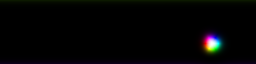

In [ ]:
from IPython.display import Image, display

for i in range(0, 26, 2):
    filename = f"session3_example2.out/m{i:06d}.png"
    display(Image(filename=filename))

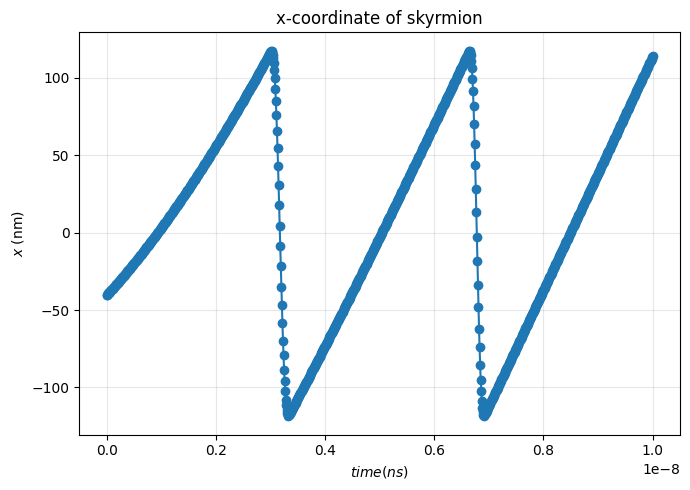

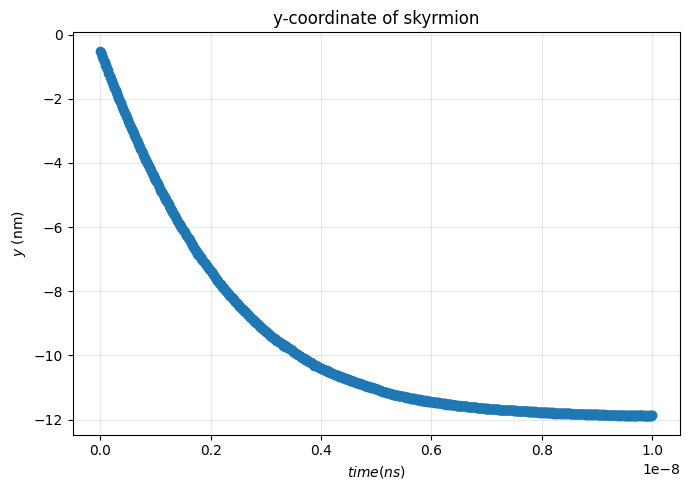

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the name of your data file
filename = "session3_example2.out/table.txt"

# Columns are counted from zero:
time, skyrm_x = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 4),
    unpack=True
)

plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_x*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$x$ (nm)")
plt.title(r"x-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()

filename = "session3_example2.out/table.txt"

# Columns are counted from zero:
time, skyrm_y = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 5),
    unpack=True
)
plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_y*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$y$ (nm)")
plt.title(r"y-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()


plt.savefig("skyrmion_pos.pdf")
plt.show()

## Exercise 2
1. Vary ratio Dind/Aex by using Aex=10e-12. What do you observe and explain?
2. Double the applied current. What happens to the skyrmion?
3. Test the case $\xi=\alpha$ and $\xi=3\alpha$. What happens? Determine the Hall angle $\theta=\tan^{-1}v_x/v_y$ for each case.
4. (Optional) Test different Skyrmion topologies by changing winding number, polarisation and skyrmion type (Neel or Bloch Skyrmion). What happens?
5. (Optional) Repeat the initial simulation at finite temperature.

## Solution Exercise 2.1

In [ ]:
f = open('example2_exercise21.mx3', 'w')
a = """\
setgridsize(256,64,1)
setcellsize(1e-9,1e-9,1e-9)
setpbc(4,0,0)

Msat = 580e3
Aex = 10e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0,0,1)
alpha = 0.1

m = neelskyrmion(-1, 1).transl(-40e-9,0,0)
minimize()

Pol = 0.4
xi = 0.2
j = vector(-1e12,0,0) // A/m2

autosave(m,4e-10)
tableAutosave(1e-11)
tableAdd(ext_bubblepos)

run(10e-9)
"""
print(a,file=f)
f.close()

In [ ]:
!mumax3 example2_exercise21.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.150
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 14fb70a6932a
//Timestamp: 2026-08-04 12:05:21
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example2_exercise21.out/
//starting GUI at http://127.0.0.1:35367
setgridsize(256, 64, 1)
setcellsize(1e-9, 1e-9, 1e-9)
setpbc(4, 0, 0)
//resizing...
Msat = 580e3
Aex = 10e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0, 0, 1)
alpha = 0.1
m = neelskyrmion(-1,

In [ ]:
!mumax3-convert -png example2_exercise21.out/*.ovf

example2_exercise21.out/m000000.ovf
example2_exercise21.out/m000001.ovf
example2_exercise21.out/m000002.ovf
example2_exercise21.out/m000003.ovf
example2_exercise21.out/m000004.ovf
example2_exercise21.out/m000005.ovf
example2_exercise21.out/m000006.ovf
example2_exercise21.out/m000007.ovf
example2_exercise21.out/m000008.ovf
example2_exercise21.out/m000009.ovf
example2_exercise21.out/m000010.ovf
example2_exercise21.out/m000011.ovf
example2_exercise21.out/m000012.ovf
example2_exercise21.out/m000013.ovf
example2_exercise21.out/m000014.ovf
example2_exercise21.out/m000015.ovf
example2_exercise21.out/m000016.ovf
example2_exercise21.out/m000017.ovf
example2_exercise21.out/m000018.ovf
example2_exercise21.out/m000019.ovf
example2_exercise21.out/m000020.ovf
example2_exercise21.out/m000021.ovf
example2_exercise21.out/m000022.ovf
example2_exercise21.out/m000023.ovf
example2_exercise21.out/m000024.ovf
example2_exercise21.out/m000025.ovf
[ ok ] example2_exercise21.out/m000002.ovf	-> example2_exercise2

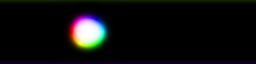

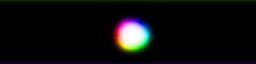

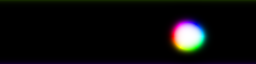

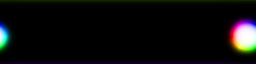

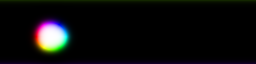

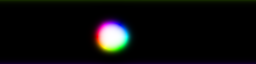

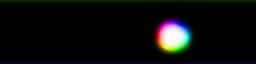

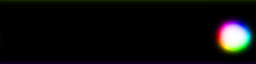

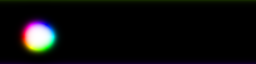

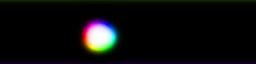

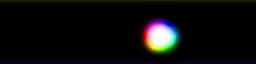

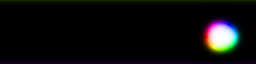

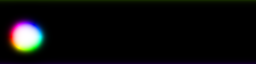

In [ ]:
from IPython.display import Image, display

for i in range(0, 26, 2):
    filename = f"example2_exercise21.out/m{i:06d}.png"
    display(Image(filename=filename))

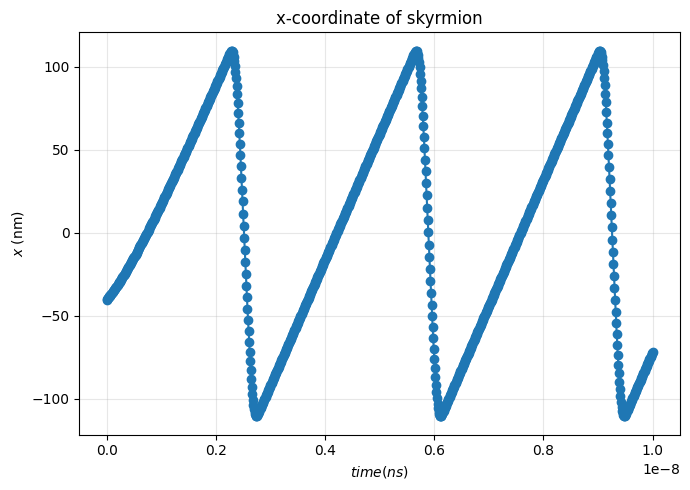

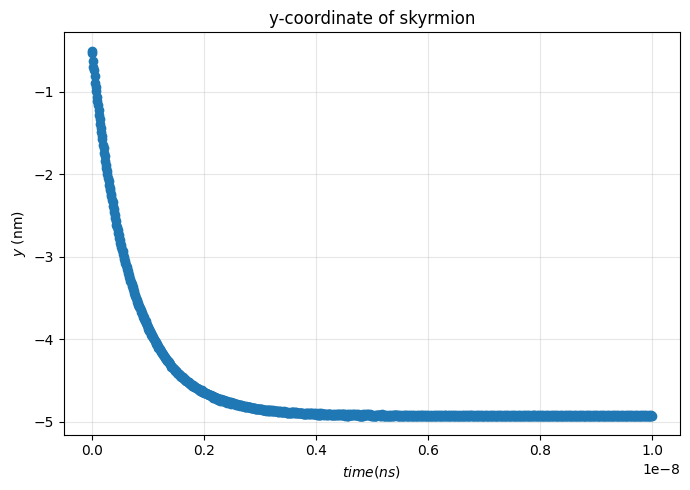

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the name of your data file
filename = "example2_exercise21.out/table.txt"

# Columns are counted from zero:
time, skyrm_x = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 4),
    unpack=True
)

plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_x*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$x$ (nm)")
plt.title(r"x-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()

filename = "example2_exercise21.out/table.txt"

# Columns are counted from zero:
time, skyrm_y = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 5),
    unpack=True
)
plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_y*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$y$ (nm)")
plt.title(r"y-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()


plt.savefig("skyrmion_pos.pdf")
plt.show()

Skyrmions get larger, gets faster, and SkyrHall effect get less dominant

## Solution Exercise 2.2

## Solution Exercise 2.3

In [ ]:
f = open('example2_exercise23_1.mx3', 'w')
a = """\
setgridsize(256,64,1)
setcellsize(1e-9,1e-9,1e-9)
setpbc(4,0,0)

Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0,0,1)
alpha = 0.1

m = neelskyrmion(-1, 1).transl(-40e-9,0,0)
minimize()

Pol = 0.4
xi = 0.1
j = vector(-1e12,0,0) // A/m2

autosave(m,4e-10)
tableAutosave(1e-11)
tableAdd(ext_bubblepos)

run(10e-9)
"""
print(a,file=f)
f.close()

In [ ]:
!mumax3 example2_exercise23_1.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.150
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 14fb70a6932a
//Timestamp: 2026-08-04 12:16:46
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example2_exercise22.out/
//starting GUI at http://127.0.0.1:35367
setgridsize(256, 64, 1)
setcellsize(1e-9, 1e-9, 1e-9)
setpbc(4, 0, 0)
//resizing...
Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0, 0, 1)
alpha = 0.1
m = neelskyrmion(-1,

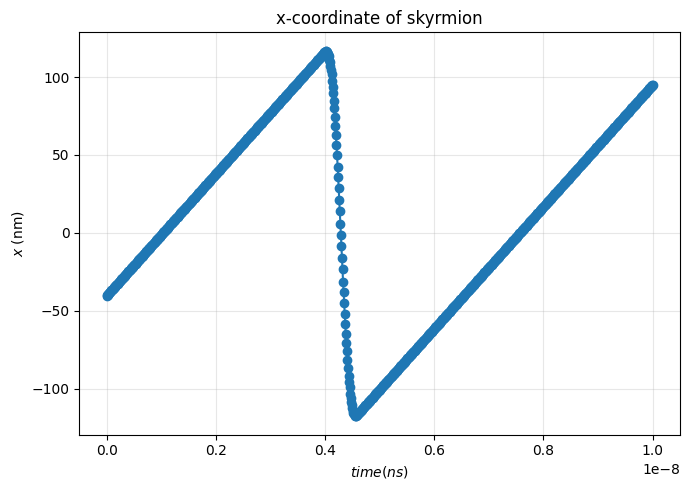

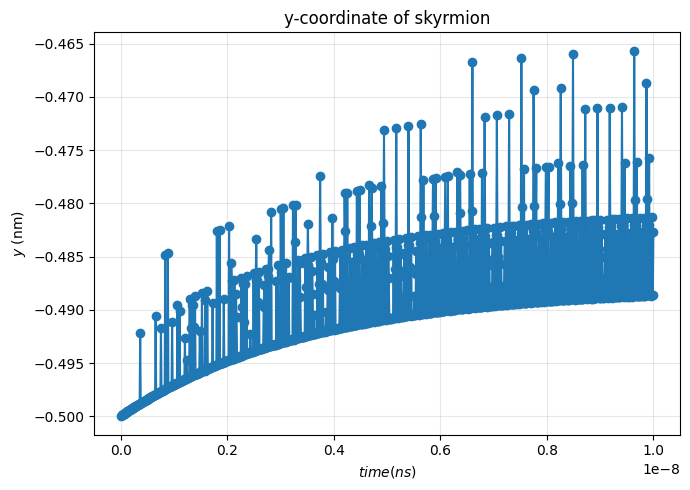

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the name of your data file
filename = "example2_exercise23_1.out/table.txt"

# Columns are counted from zero:
time, skyrm_x = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 4),
    unpack=True
)

plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_x*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$x$ (nm)")
plt.title(r"x-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()

filename = "example2_exercise23_1.out/table.txt"

# Columns are counted from zero:
time, skyrm_y = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 5),
    unpack=True
)
plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_y*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$y$ (nm)")
plt.title(r"y-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()


plt.savefig("skyrmion_pos.pdf")
plt.show()

# Position in nm:
x_nm = skyrm_x * 1e9
y_nm = skyrm_y * 1e9
#vx_fit, x0 = np.polyfit(time, x_nm, 1)
#vy_fit, y0 = np.polyfit(time, y_nm, 1)
#print(f"vx from linear fit = {vx_fit:.6e} m/s")
#print(f"vy from linear fit = {vy_fit:.6e} m/s")
#print(f"vx/vy from linear fit = {vx_fit / vy_fit:.6e}")
# Since nm/ns is numerically equal to m/s:

# vx = np.gradient(x_nm, time)   # nm/ns = m/s
# vy = np.gradient(y_nm, time)   # nm/ns = m/s
# print(vx[0])
# plt.plot(time, vx, marker="o", linestyle="-")
# plt.xlim(0,0.3e-8)

In [ ]:
f = open('example2_exercise23_2.mx3', 'w')
a = """\
setgridsize(256,64,1)
setcellsize(1e-9,1e-9,1e-9)
setpbc(4,0,0)

Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0,0,1)
alpha = 0.1

m = neelskyrmion(-1, 1).transl(-40e-9,0,0)
minimize()

Pol = 0.4
xi = 0.3
j = vector(-1e12,0,0) // A/m2

autosave(m,4e-10)
tableAutosave(1e-11)
tableAdd(ext_bubblepos)

run(10e-9)
"""
print(a,file=f)
f.close()

In [ ]:
!mumax3 example2_exercise23_2.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.150
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 14fb70a6932a
//Timestamp: 2026-08-04 12:44:32
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example2_exercise22_2.out/
//starting GUI at http://127.0.0.1:35367
setgridsize(256, 64, 1)
setcellsize(1e-9, 1e-9, 1e-9)
setpbc(4, 0, 0)
//resizing...
Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0, 0, 1)
alpha = 0.1
m = neelskyrmion(-

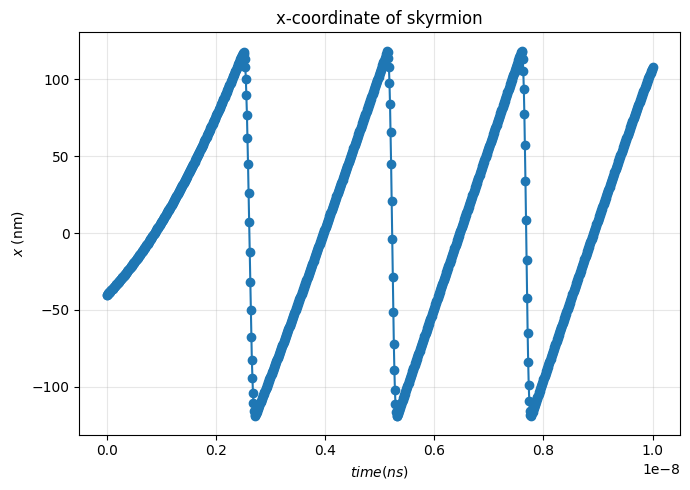

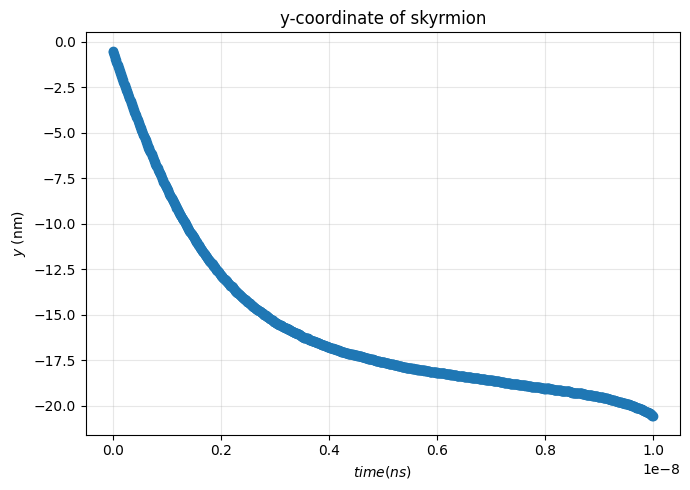

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the name of your data file
filename = "example2_exercise23_2.out/table.txt"

# Columns are counted from zero:
time, skyrm_x = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 4),
    unpack=True
)

plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_x*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$x$ (nm)")
plt.title(r"x-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()

filename = "example2_exercise23_2.out/table.txt"

# Columns are counted from zero:
time, skyrm_y = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 5),
    unpack=True
)
plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_y*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$y$ (nm)")
plt.title(r"y-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()


plt.savefig("skyrmion_pos.pdf")
plt.show()

# Position in nm:
x_nm = skyrm_x * 1e9
y_nm = skyrm_y * 1e9
#vx_fit, x0 = np.polyfit(time, x_nm, 1)
#vy_fit, y0 = np.polyfit(time, y_nm, 1)
#print(f"vx from linear fit = {vx_fit:.6e} m/s")
#print(f"vy from linear fit = {vy_fit:.6e} m/s")
#print(f"vx/vy from linear fit = {vx_fit / vy_fit:.6e}")
# Since nm/ns is numerically equal to m/s:

# vx = np.gradient(x_nm, time)   # nm/ns = m/s
# vy = np.gradient(y_nm, time)   # nm/ns = m/s
# print(vx[0])
# plt.plot(time, vx, marker="o", linestyle="-")
# plt.xlim(0,0.3e-8)

## Solution Exercise 2.4

Neel Skyrmion, winding 1 and polarisation 1 - not stable

Neel Skyrmion, winding 1 and polarisation -1 - stable

Neel Skyrmion, winding -1 and polarisation -1 -

Bloch Skyrmion, winding -1 and polarisation 1 -

Bloch Skyrmion, winding 1 and polarisation 1 -

Bloch Skyrmion, winding 1 and polarisation -1 -

Bloch Skyrmion, winding -1 and polarisation -1 -

In [ ]:
# @title
f = open('example2_exercise24.mx3', 'w')
a = """\
setgridsize(256,64,1)
setcellsize(1e-9,1e-9,1e-9)
setpbc(4,0,0)

Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0,0,1)
alpha = 0.1

m = neelskyrmion(1, -1).transl(-40e-9,0,0)
minimize()

Pol = 0.4
xi = 0.2
j = vector(-1e12,0,0) // A/m2

autosave(m,4e-10)
tableAutosave(1e-11)
tableAdd(ext_bubblepos)

run(10e-9)
"""
print(a,file=f)
f.close()

In [ ]:
!mumax3 example2_exercise24.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.150
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 14fb70a6932a
//Timestamp: 2026-08-04 13:06:30
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example2_exercise24.out/
//starting GUI at http://127.0.0.1:35367
setgridsize(256, 64, 1)
setcellsize(1e-9, 1e-9, 1e-9)
setpbc(4, 0, 0)
//resizing...
Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0, 0, 1)
alpha = 0.1
m = neelskyrmion(1, 

In [ ]:
!mumax3-convert -png example2_exercise24.out/*.ovf

example2_exercise24.out/m000000.ovf
example2_exercise24.out/m000001.ovf
example2_exercise24.out/m000002.ovf
example2_exercise24.out/m000003.ovf
example2_exercise24.out/m000004.ovf
example2_exercise24.out/m000005.ovf
example2_exercise24.out/m000006.ovf
example2_exercise24.out/m000007.ovf
example2_exercise24.out/m000008.ovf
example2_exercise24.out/m000009.ovf
example2_exercise24.out/m000010.ovf
example2_exercise24.out/m000011.ovf
example2_exercise24.out/m000012.ovf
example2_exercise24.out/m000013.ovf
example2_exercise24.out/m000014.ovf
example2_exercise24.out/m000015.ovf
example2_exercise24.out/m000016.ovf
example2_exercise24.out/m000017.ovf
example2_exercise24.out/m000018.ovf
example2_exercise24.out/m000019.ovf
example2_exercise24.out/m000020.ovf
example2_exercise24.out/m000021.ovf
example2_exercise24.out/m000022.ovf
example2_exercise24.out/m000023.ovf
example2_exercise24.out/m000024.ovf
example2_exercise24.out/m000025.ovf
[ ok ] example2_exercise24.out/m000001.ovf	-> example2_exercise2

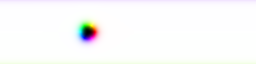

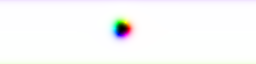

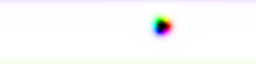

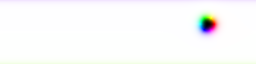

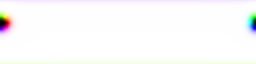

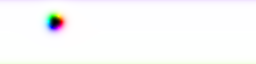

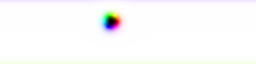

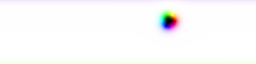

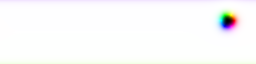

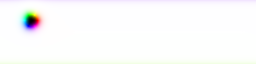

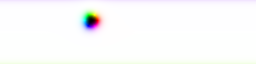

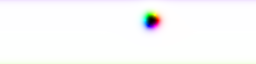

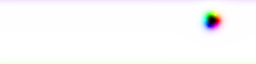

In [ ]:
from IPython.display import Image, display

for i in range(0, 26, 2):
    filename = f"example2_exercise24.out/m{i:06d}.png"
    display(Image(filename=filename))

# Example 3 of Mumax Tutorial - Hysteresis

Task:
Calculate the hysteresis loop for an
external field parallel to the long
axis.

In [ ]:
f = open('example3.mx3', 'w')
a = """\
SetGridsize(192,384, 1)
SetCellsize(1000e-9/192,2000e-9/384,20e-9)

Msat  = 800e3
Aex   = 13e-12
alpha = 0.02
Ku1   = 5e2
anisu = vector(0,1,0)

m = uniform(-0.1,-1,0)

angle  := pi/180  //1 degree
B_ext   = vector( -0.05*sin(angle) , -0.05*cos(angle) , 0)
tableadd(B_ext)
relax()

B_min  := -0.05
B_max  :=  0.05
B_step :=  0.001

//ramp the field up
for B:=B_min; B<=B_max; B+=B_step {
    B_ext = vector(B*sin(angle), B*cos(angle), 0)
    minimize()
    tablesave()
    snapshot(m)
}

//ramp the field down
for B:=B_max; B>=B_min; B-=B_step {
    B_ext = vector(B*sin(angle), B*cos(angle), 0)
    minimize()
    tablesave()
    snapshot(m)
}
"""
print(a,file=f)
f.close()

In [ ]:
!mumax3 example3.mx3

/bin/bash: line 1: mumax3: command not found
